# CPCV Lab — Implementación De Prado (2018)
### Combinatorial Purged Cross-Validation sobre datos sintéticos

Este notebook implementa **Combinatorial Purged Cross-Validation (CPCV)** siguiendo
el marco propuesto por Marcos López de Prado en *Advances in Financial Machine Learning* (2018),
Capítulos 7 y 12.

El objetivo es doble: (1) auditar paso a paso cómo el purging y el embargo protegen
al modelo de look-ahead bias, y (2) comparar CPCV contra los métodos estándar de CV
que se usan típicamente en proyectos de trading — mostrando por qué importa la diferencia.

**Estructura:**
1. Mercado sintético y visualización
2. Features y etiquetas
3. `getTrainTimes` — purge del training set
4. `getEmbargoTimes` — embargo post-test
5. `PurgedKFold` — integración purge + embargo compatible con sklearn
6. `cvScore` — score de CV con PurgedKFold
7. Splits CPCV combinatorios
8. Auditoría del Split 0 — ejemplo detallado
9. Corrida completa y Sharpe por path
10. Comparación: CCV · CCV+Purge · CCV+Embargo · CPCV · WalkForward · KFold
11. Los tres escenarios: learnable · noise · shock

---
## 1 · Mercado sintético

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from math import comb

np.random.seed(42)


def _latent_signal(n_obs: int, seed: int = 42):
    rng    = np.random.default_rng(seed)
    signal = np.zeros(n_obs)
    regime = np.zeros(n_obs)
    regime[0] = 1.0
    for t in range(1, n_obs):
        if rng.random() < 0.04:
            regime[t] = -regime[t - 1] if regime[t - 1] != 0 else 1.0
        else:
            regime[t] = regime[t - 1]
        signal[t] = 0.92 * signal[t - 1] + 0.55 * regime[t] + rng.normal(0, 0.35)
    return signal, regime


def _build_features(prices: pd.Series) -> pd.DataFrame:
    log_ret = np.log(prices / prices.shift(1))
    return pd.DataFrame({
        "feature_x": log_ret.rolling(3).sum().shift(1),
    }).dropna()


def generate_synthetic_market(scenario: str, n_obs: int = 960,
                               horizon: int = 5, seed: int = 42) -> dict:
    dates = pd.bdate_range("2018-01-01", periods=n_obs, freq="B")
    rng   = np.random.default_rng(seed)

    if scenario in {"learnable", "shock"}:
        signal, regime = _latent_signal(n_obs, seed=seed)
        eps      = rng.normal(0, 0.004, size=n_obs)
        base_ret = 0.00015 + 0.0028 * np.tanh(signal / 1.5) + 0.0010 * regime + eps
        if scenario == "shock":
            sc  = int(n_obs * 0.58)
            pat = np.array([-0.075, -0.055, -0.035, -0.018, 0.020, 0.045, 0.060, 0.038])
            end = min(sc + len(pat), n_obs)
            base_ret[sc:end] += pat[: end - sc]
    else:
        signal = regime = np.zeros(n_obs)
        base_ret = rng.normal(0, 0.007, size=n_obs)

    prices = pd.Series(100 * np.exp(np.cumsum(base_ret)), index=dates, name="Close")
    X      = _build_features(prices)

    fut  = prices.reindex(X.index).shift(-horizon)
    rfwd = np.log(fut / prices.reindex(X.index))
    y    = (rfwd > 0).astype(int).dropna()
    rfwd = rfwd.reindex(y.index)
    X    = X.reindex(y.index)

    t1_vals = []
    for ts in y.index:
        pos     = X.index.get_loc(ts)
        end_pos = min(pos + horizon, len(X.index) - 1)
        t1_vals.append(X.index[end_pos])
    t1 = pd.Series(t1_vals, index=y.index, name="t1")

    price_df = pd.DataFrame({
        "Close": prices,
        "synthetic_log_return": base_ret,
        "latent_signal": signal,
        "regime": regime,
    }, index=dates).reindex(y.index)

    return {
        "scenario": scenario,
        "prices": price_df,
        "X": X,
        "y": y,
        "t1": t1,
        "ret_fwd": rfwd,
    }


learnable = generate_synthetic_market("learnable", n_obs=960, horizon=5, seed=42)
noise     = generate_synthetic_market("noise",     n_obs=960, horizon=5, seed=123)
shock     = generate_synthetic_market("shock",     n_obs=960, horizon=5, seed=42)

prices  = learnable["prices"]
X       = learnable["X"]
y       = learnable["y"]
t1      = learnable["t1"]
ret_fwd = learnable["ret_fwd"]

print(f"Observaciones : {len(X)}")
print(f"Rango         : {X.index[0].date()} -> {X.index[-1].date()}")
print(X.head().to_string())


Observaciones : 941
Rango         : 2018-01-26 -> 2021-09-03


,count,mean,std,min,25%,50%,75%,max
log_ret,941.0,0.0013,0.0050,-0.0129,-0.0018,0.0016,0.0048,0.0167
ret_3,941.0,0.0040,0.0115,-0.0294,-0.0040,0.0061,0.0124,0.0348
ret_5,941.0,0.0066,0.0176,-0.0457,-0.0060,0.0109,0.0198,0.0457
ma_gap_5,941.0,0.0027,0.0075,-0.0206,-0.0026,0.0038,0.0082,0.0238
ma_gap_10,941.0,0.0060,0.0150,-0.0308,-0.0053,0.0103,0.0176,0.0373
trend_gap,941.0,0.0101,0.0229,-0.0413,-0.0091,0.0183,0.0279,0.0519
vol_5,941.0,0.0037,0.0014,0.0007,0.0027,0.0035,0.0046,0.0087
vol_10,941.0,0.0039,0.0010,0.0018,0.0032,0.0038,0.0045,0.0081
zscore_10,941.0,0.5096,1.3152,-2.5979,-0.8835,1.1501,1.5284,2.5149
rsi_8,941.0,0.6508,0.3605,0.0000,0.2849,0.8141,0.9569,1.0000


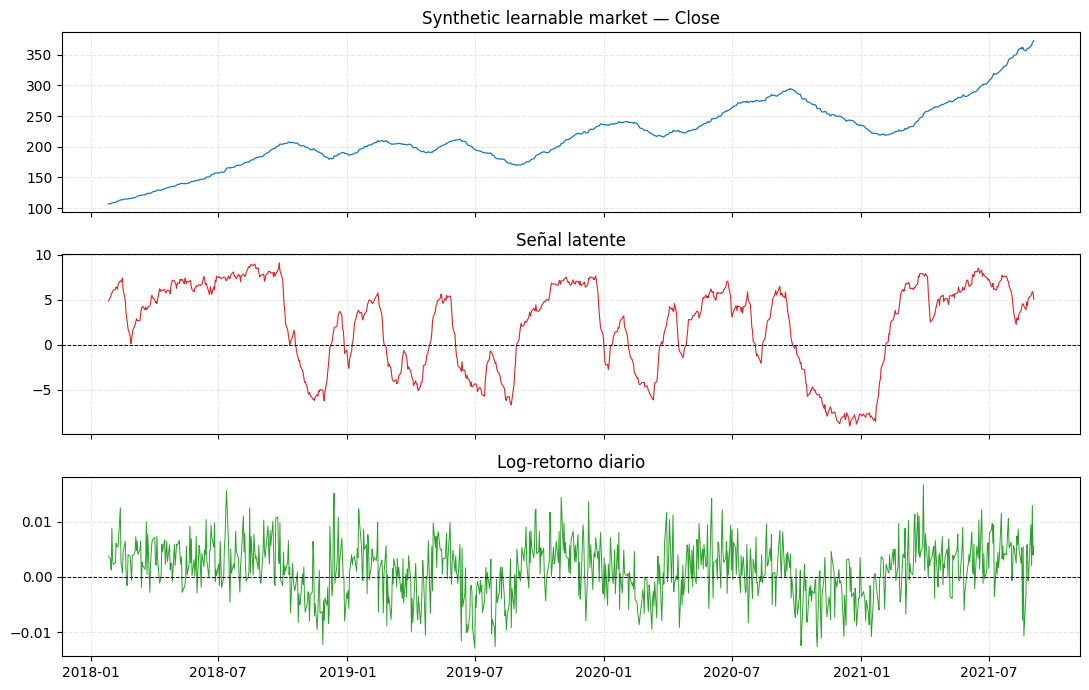

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(prices.index, prices["Close"],                color="#1f77b4", lw=0.9)
axes[0].set_title("Synthetic learnable market — Close"); axes[0].grid(alpha=0.3, ls="--")
axes[1].plot(prices.index, prices["latent_signal"],        color="#d62728", lw=0.8)
axes[1].axhline(0, color="black", ls="--", lw=0.7)
axes[1].set_title("Señal latente"); axes[1].grid(alpha=0.3, ls="--")
axes[2].plot(prices.index, prices["synthetic_log_return"], color="#2ca02c", lw=0.7)
axes[2].axhline(0, color="black", ls="--", lw=0.7)
axes[2].set_title("Log-retorno diario"); axes[2].grid(alpha=0.3, ls="--")
plt.tight_layout(); plt.show()

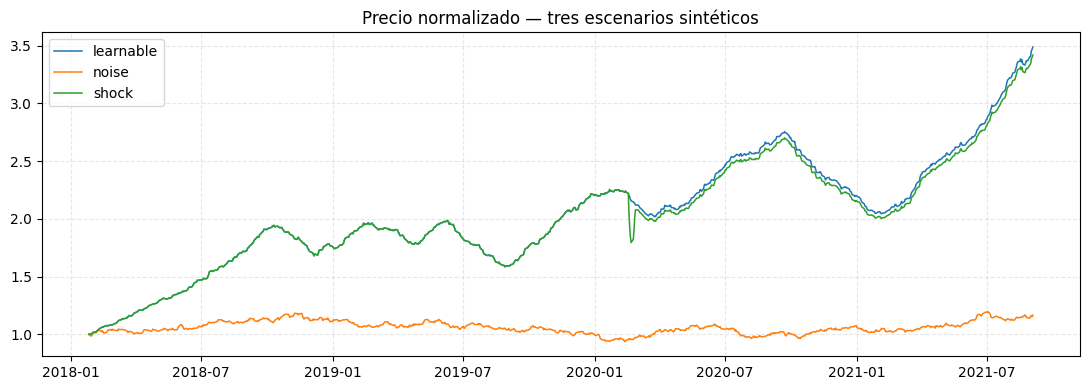

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, sc in [("learnable", learnable), ("noise", noise), ("shock", shock)]:
    n = sc["prices"]["Close"] / sc["prices"]["Close"].iloc[0]
    ax.plot(n.index, n.values, lw=1.1, label=name)
ax.set_title("Precio normalizado — tres escenarios sintéticos")
ax.legend(); ax.grid(alpha=0.3, ls="--"); plt.tight_layout(); plt.show()

---
## 2 · Features, etiquetas y `t1`

In [4]:
feature_df = (
    prices[["Close", "synthetic_log_return", "latent_signal", "regime"]]
    .join(X)
    .assign(ret_fwd_5d=ret_fwd, target=y, t1=t1)
)
feature_df.head(10)


,Close,synthetic_log_return,latent_signal,regime,log_ret,ret_3,ret_5,ma_gap_5,ma_gap_10,trend_gap,vol_5,vol_10,zscore_10,rsi_8,label,t1,ret_fwd
2018-01-26,106.895055,0.003742,4.864563,1.0,0.003742,0.011298,0.017207,0.008608,0.019375,0.030197,0.003159,0.002884,1.402874,1.0,1,2018-02-02,0.018831
2018-01-29,107.238253,0.003205,5.253106,1.0,0.003205,0.014404,0.019914,0.007825,0.017988,0.030800,0.002732,0.002799,1.406638,1.0,1,2018-02-05,0.018165
2018-01-30,107.369482,0.001223,5.572961,1.0,0.001223,0.008170,0.015726,0.005891,0.015175,0.030353,0.002825,0.002840,1.292067,1.0,1,2018-02-06,0.023021
2018-01-31,108.322573,0.008838,5.758381,1.0,0.008838,0.013266,0.024465,0.009867,0.019622,0.031541,0.003153,0.003228,1.705038,1.0,1,2018-02-07,0.019594
2018-02-01,108.683867,0.003330,5.924251,1.0,0.003330,0.013390,0.020338,0.009118,0.018976,0.032047,0.002839,0.002923,1.594049,1.0,1,2018-02-08,0.021863
2018-02-02,108.927047,0.002235,6.078570,1.0,0.002235,0.014402,0.018831,0.007574,0.017577,0.031904,0.002960,0.002891,1.427368,1.0,1,2018-02-09,0.025301
2018-02-05,109.204069,0.002540,6.165937,1.0,0.002540,0.008105,0.018165,0.006476,0.016291,0.031407,0.003006,0.002714,1.358662,1.0,1,2018-02-12,0.035277
2018-02-06,109.869854,0.006078,6.443613,1.0,0.006078,0.010853,0.023021,0.007967,0.018529,0.031808,0.002810,0.002766,1.501866,1.0,1,2018-02-13,0.031523
2018-02-07,110.465930,0.005411,6.366239,1.0,0.005411,0.014029,0.019594,0.009465,0.019555,0.031369,0.001730,0.002452,1.603451,1.0,1,2018-02-14,0.028013
2018-02-08,111.086215,0.005599,6.183332,1.0,0.005599,0.017088,0.021863,0.010696,0.020954,0.031306,0.001832,0.002258,1.626650,1.0,1,2018-02-15,0.023108


In [5]:
print("Distribución del target binario:")
print(y.value_counts().rename({0: "Baja (0)", 1: "Sube (1)"}))
print()
print("Feature única usada por el modelo:")
print(X.describe().T.round(6).to_string())
print()
print("t1 — primeras entradas (fin del label de cada obs):")
print(t1.head(5).to_string())


Distribución de la etiqueta binaria:
Close
Sube (1)    625
Baja (0)    316
Name: count, dtype: int64

t1 — primeras entradas (fin del label de cada obs):
2018-01-26   2018-02-02
2018-01-29   2018-02-05
2018-01-30   2018-02-06
2018-01-31   2018-02-07
2018-02-01   2018-02-08
Freq: B


---
## 3 · Purge del training set — `getTrainTimes`

Cuando los labels se construyen mirando hacia adelante (e.g. retorno a 5 días),
una observación de entrenamiento cuyo label se solapa en tiempo con cualquier
observación del test introduce **look-ahead bias** aunque la feature en sí no lo haga.

`getTrainTimes` elimina del training set todas las observaciones con alguno de estos
tres tipos de solapamiento:

| Caso | Condición |
|------|-----------|
| Train empieza dentro del test | `t_start_train ∈ [t_start_test, t_end_test]` |
| Train termina dentro del test | `t_end_train ∈ [t_start_test, t_end_test]` |
| Train envuelve al test | `t_start ≤ t_start_test` y `t_end ≥ t_end_test` |

In [6]:
def getTrainTimes(t1: pd.Series, testTimes: pd.Series) -> pd.Series:
    """
    Elimina del training set las observaciones cuyos labels se solapan
    en tiempo con el periodo de test — De Prado (2018), Cap. 7.

    Parámetros
    ----------
    t1        : Series  index = t_start del label,  value = t_end del label
    testTimes : Series con los intervalos del test (mismo formato)

    Retorna
    -------
    t1 filtrado — sin las obs que generarían look-ahead bias
    """
    trn = t1.copy(deep=True)
    for i, j in testTimes.items():
        df0 = trn[(trn.index >= i) & (trn.index <= j)].index   # empieza dentro del test
        df1 = trn[(trn.index <= i) & (trn.values >= i)].index  # termina dentro del test
        df2 = trn[(trn.index <= i) & (trn.values >= j)].index  # envuelve al test
        trn = trn.drop(df0.union(df1).union(df2))
    return trn

---
## 4 · Embargo — `getEmbargoTimes`

Incluso después del purge puede filtrarse información indirecta: los features de las observaciones inmediatamente posteriores al test se calculan con rolling windows que incorporan datos del test. El **embargo** elimina una ventana adicional de observaciones justo después de cada bloque de test.

In [7]:
def getEmbargoTimes(times: pd.Index, pctEmbargo: float) -> pd.Series:
    """
    Mapea cada timestamp al primer timestamp post-embargo — De Prado (2018), Cap. 7.

    Parámetros
    ----------
    times      : DatetimeIndex con todos los timestamps del dataset
    pctEmbargo : fracción del dataset que define el tamaño del embargo

    Retorna
    -------
    Series: index = timestamp,  value = primer timestamp post-embargo
    """
    step = int(times.shape[0] * pctEmbargo)
    if step == 0:
        mbrg = pd.Series(times, index=times)
    else:
        mbrg = pd.Series(times[step:], index=times[:-step])
        mbrg = pd.concat([mbrg, pd.Series(times[-1], index=times[-step:])])
    return mbrg

In [8]:
N, k       = 6, 2
pctEmbargo = 0.01
n_obs      = len(X)

mbrg = getEmbargoTimes(X.index, pctEmbargo)
step = int(len(X) * pctEmbargo)
print(f"pctEmbargo = {pctEmbargo:.1%}  ->  step = {step} observaciones")
print()
print("Muestra del mapeo (timestamp -> primer obs post-embargo):")
print(mbrg.head(8).to_frame("embargo_end").to_string())

pctEmbargo = 1.0%  ->  step = 9 observaciones

Muestra del mapeo (timestamp -> primer obs post-embargo):
           embargo_end
2018-01-26  2018-02-08
2018-01-29  2018-02-09
2018-01-30  2018-02-12
2018-01-31  2018-02-13
2018-02-01  2018-02-14
2018-02-02  2018-02-15
2018-02-05  2018-02-16
2018-02-06  2018-02-19


---
## 5 · `PurgedKFold` — KFold con purge y embargo integrados

`PurgedKFold` extiende el `KFold` de sklearn incorporando las dos operaciones
anteriores de forma transparente. Cualquier pipeline que acepte un `cv` de sklearn
puede usar `PurgedKFold` directamente sin cambios adicionales.

In [9]:
try:
    from sklearn.model_selection import _BaseKFold
except ImportError:
    from sklearn.model_selection._split import _BaseKFold


class PurgedKFold(_BaseKFold):
    """
    KFold con purging y embargo, compatible con la API de sklearn — De Prado (2018), Cap. 7.

    Parámetros
    ----------
    n_splits   : número de folds
    t1         : Series  index = t_start del label,  value = t_end
    pctEmbargo : fracción del dataset para el embargo
    """

    def __init__(self, n_splits: int = 3, t1: pd.Series = None,
                 pctEmbargo: float = 0.0) -> None:
        if not isinstance(t1, pd.Series):
            raise ValueError("t1 must be a pd.Series")
        super().__init__(n_splits=n_splits, shuffle=False, random_state=None)
        self.t1         = t1
        self.pctEmbargo = pctEmbargo

    def split(self, X: pd.DataFrame, y=None, groups=None):
        if (X.index == self.t1.index).sum() != len(self.t1):
            raise ValueError("X and t1 must share the same index")

        indices     = np.arange(X.shape[0])
        mbrg        = int(X.shape[0] * self.pctEmbargo)
        test_starts = [(i[0], i[-1] + 1)
                       for i in np.array_split(indices, self.n_splits)]

        for i, j in test_starts:
            t0        = self.t1.index[i]
            test_idx  = indices[i:j]
            maxT1Idx  = self.t1.index.searchsorted(self.t1.iloc[test_idx].max())
            train_idx = self.t1.index.searchsorted(
                self.t1[self.t1 <= t0].index
            )
            if maxT1Idx < X.shape[0]:
                train_idx = np.concatenate((train_idx, indices[maxT1Idx + mbrg:]))
            yield train_idx, test_idx

In [10]:
pkf    = PurgedKFold(n_splits=N, t1=t1, pctEmbargo=pctEmbargo)
splits = list(pkf.split(X))

rows = []
for sid, (tr, te) in enumerate(splits):
    rows.append({
        "split_id"   : sid,
        "n_train"    : len(tr),
        "n_test"     : len(te),
        "test_start" : X.index[te[0]].date(),
        "test_end"   : X.index[te[-1]].date(),
        "train_start": X.index[tr[0]].date(),
        "train_end"  : X.index[tr[-1]].date(),
    })

pd.DataFrame(rows)


,split_id,n_train,n_test,test_start,test_end,train_start,train_end
0,0,771,157,2018-01-26,2018-09-03,2018-09-21,2021-09-03
1,1,767,157,2018-09-04,2019-04-10,2018-01-26,2021-09-03
2,2,767,157,2019-04-11,2019-11-15,2018-01-26,2021-09-03
3,3,767,157,2019-11-18,2020-06-23,2018-01-26,2021-09-03
4,4,767,157,2020-06-24,2021-01-28,2018-01-26,2021-09-03
5,5,781,156,2021-01-29,2021-09-03,2018-01-26,2021-01-22


---
## 6 · `cvScore` — score de CV con PurgedKFold

`cvScore` envuelve la lógica de scoring fold a fold. Soporta `neg_log_loss` y `accuracy`.

In [11]:
from sklearn.metrics import accuracy_score, log_loss


def cvScore(clf, X: pd.DataFrame, y: pd.Series,
            sample_weight: pd.Series,
            scoring: str = "neg_log_loss",
            t1: pd.Series = None,
            cv: int = None,
            cvGen=None,
            pctEmbargo: float = None) -> np.ndarray:
    """
    Calcula el score de CV sobre cada fold generado por PurgedKFold — De Prado (2018), Cap. 7.

    Parámetros
    ----------
    clf          : clasificador sklearn con predict_proba
    X, y         : features y etiquetas
    sample_weight: pesos por observación
    scoring      : 'neg_log_loss' | 'accuracy'
    t1           : Series con el t_end de cada label
    cv           : número de folds (si cvGen es None)
    cvGen        : generador de splits pre-construido
    pctEmbargo   : fracción de embargo

    Retorna
    -------
    np.ndarray con el score de cada fold
    """
    if scoring not in ("neg_log_loss", "accuracy"):
        raise ValueError("scoring must be neg_log_loss or accuracy")

    if cvGen is None:
        cvGen = PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)

    scores = []
    for train, test in cvGen.split(X=X):
        fit = clf.fit(
            X.iloc[train], y.iloc[train],
            sample_weight=sample_weight.iloc[train].values,
        )
        if scoring == "neg_log_loss":
            prob = fit.predict_proba(X.iloc[test])
            s    = -log_loss(y.iloc[test], prob,
                             sample_weight=sample_weight.iloc[test].values,
                             labels=clf.classes_)
        else:
            pred = fit.predict(X.iloc[test])
            s    = accuracy_score(y.iloc[test], pred,
                                  sample_weight=sample_weight.iloc[test].values)
        scores.append(s)

    return np.array(scores)


In [12]:
from sklearn.ensemble import RandomForestClassifier

MODEL_NAME = "RandomForestClassifier"
MODEL_PARAMS = dict(
    n_estimators=24,
    max_depth=3,
    min_samples_leaf=25,
    random_state=42,
    n_jobs=-1,
)


def make_clf():
    return RandomForestClassifier(**MODEL_PARAMS)


clf_rf = make_clf()
sw     = pd.Series(np.ones(len(y)), index=y.index)

cv_gen      = PurgedKFold(n_splits=N, t1=t1, pctEmbargo=pctEmbargo)
fold_scores = cvScore(clf_rf, X, y, sample_weight=sw,
                      scoring="neg_log_loss", cvGen=cv_gen)

print(f"Modelo base del notebook: {MODEL_NAME}")
print(MODEL_PARAMS)
print()
print("neg_log_loss por fold (PurgedKFold, learnable):")
for i, s in enumerate(fold_scores):
    print(f"  fold {i}: {s:.4f}")
print(f"\nMedia: {fold_scores.mean():.4f}  |  Std: {fold_scores.std():.4f}")


neg_log_loss por fold (PurgedKFold, learnable):
  fold 0: -0.2181
  fold 1: -0.6422
  fold 2: -0.3549
  fold 3: -0.4689
  fold 4: -0.4990
  fold 5: -0.3915

Media: -0.4291  |  Std: 0.1312


---
## 7 · Splits CPCV — extensión combinatoria

Con N=6 grupos y k=2 grupos de test por combinación, CPCV genera C(6,2) = **15 splits**
y φ = 15·2/6 = **5 paths** OOS que cubren el dataset completo sin overlap.

> **Nota sobre test discontiguo:** en splits como (grupos 0 y 2), el test no es un bloque
> único sino dos bloques separados. El embargo se aplica por bloque, no sobre el intervalo
> global [min_test, max_test], para no eliminar erróneamente el train intermedio.

In [ ]:
class CombinatorialPurgedKFold:
    """
    Splitter combinatorio con purge y embargo inspirado en De Prado.

    Genera combinaciones de `k` grupos de test sobre `N` grupos totales y,
    para cada combinación, aplica:
      1. purge del training set frente a los labels del test,
      2. embargo por cada bloque contiguo dentro del test.

    Retorna tuplas:
      (raw_train_idx, test_idx, final_train_idx, test_groups)
    """

    def __init__(self, n_groups: int, n_test_groups: int,
                 t1: pd.Series, pctEmbargo: float = 0.01) -> None:
        if not isinstance(t1, pd.Series):
            raise ValueError("t1 must be a pd.Series")
        if n_groups < 2:
            raise ValueError("n_groups must be >= 2")
        if n_test_groups < 1 or n_test_groups >= n_groups:
            raise ValueError("n_test_groups must be in [1, n_groups)")
        self.n_groups = n_groups
        self.n_test_groups = n_test_groups
        self.t1 = t1
        self.pctEmbargo = pctEmbargo

    def split(self, X: pd.DataFrame, y=None, groups=None):
        if not X.index.equals(self.t1.index):
            raise ValueError("X and t1 must share the same index")

        n_obs = len(X)
        base_groups = np.array_split(np.arange(n_obs), self.n_groups)
        mbrg = getEmbargoTimes(X.index, self.pctEmbargo)

        for test_groups in combinations(range(self.n_groups), self.n_test_groups):
            test_idx = np.concatenate([base_groups[g] for g in test_groups])
            raw_train_idx = np.concatenate([
                base_groups[g] for g in range(self.n_groups)
                if g not in test_groups
            ])

            testTimes = self.t1.iloc[test_idx]
            train_t1_raw = self.t1.iloc[raw_train_idx]
            train_t1_purged = getTrainTimes(train_t1_raw, testTimes)

            kept = np.array(train_t1_purged.index)
            blocked = np.zeros(len(kept), dtype=bool)
            sorted_test = np.sort(test_idx)

            if len(sorted_test) > 0:
                breaks = np.where(np.diff(sorted_test) > 1)[0] + 1
                blocks = np.split(sorted_test, breaks)
                train_times = pd.Index(kept)
                for block in blocks:
                    block_end = X.index[block[-1]]
                    embargo_end = mbrg.get(block_end, block_end)
                    in_emb = np.array((train_times > block_end) & (train_times <= embargo_end))
                    blocked |= in_emb

            final_train_idx = np.array([X.index.get_loc(ts) for ts in kept[~blocked]])
            yield raw_train_idx, test_idx, final_train_idx, test_groups


In [56]:
cpcv = CombinatorialPurgedKFold(
    n_groups=N,
    n_test_groups=k,
    t1=t1,
    pctEmbargo=pctEmbargo,
)

rows = []
for sid, (raw_tr, te, final_tr, tg) in enumerate(cpcv.split(X)):
    rows.append({
        "split_id"     : sid,
        "test_groups"  : tg,
        "n_train_raw"  : len(raw_tr),
        "n_train_final": len(final_tr),
        "n_removed"    : len(raw_tr) - len(final_tr),
        "n_test"       : len(te),
        "test_start"   : X.index[te[0]].date(),
        "test_end"     : X.index[te[-1]].date(),
    })

split_table = pd.DataFrame(rows)
split_table


UnboundLocalError: cannot access local variable 'final_train_idx' where it is not associated with a value

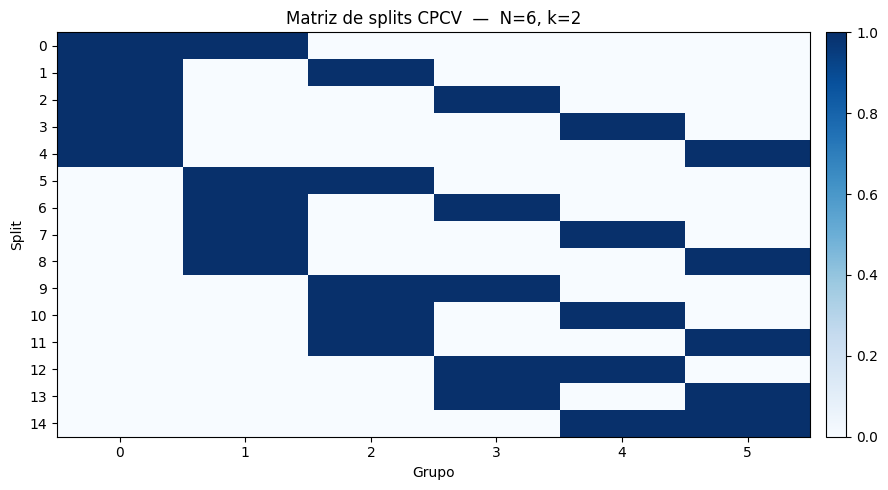

In [15]:
split_matrix = np.zeros((len(split_table), N), dtype=int)
for i, tg in enumerate(split_table["test_groups"]):
    for g in tg:
        split_matrix[i, g] = 1

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(split_matrix, aspect="auto", cmap="Blues")
ax.set_xlabel("Grupo"); ax.set_ylabel("Split")
ax.set_title(f"Matriz de splits CPCV  —  N={N}, k={k}")
ax.set_xticks(range(N)); ax.set_yticks(range(len(split_table)))
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout(); plt.show()

---
## 8 · Auditoría del Split 0 — ejemplo detallado

Antes de correr todos los splits, vale la pena ver en detalle qué pasa en el
**Split 0** (test = grupos 0 y 1) para entender exactamente qué observaciones
se eliminan y por qué.

El test ocupa `[0, 313]` — de `2018-01-26` a `2019-04-10`.  
El train raw son `[314, 940]` — de `2019-04-11` a `2021-09-03`.

In [16]:
# Reconstruir Split 0 paso a paso
groups_0    = np.array_split(np.arange(n_obs), N)
test_idx_0  = np.concatenate([groups_0[g] for g in (0, 1)])
train_idx_0 = np.concatenate([groups_0[g] for g in range(N) if g not in (0, 1)])

testTimes_0    = t1.iloc[test_idx_0]
train_t1_raw_0 = t1.iloc[train_idx_0]

print(f"Test     : [{test_idx_0[0]}, {test_idx_0[-1]}]  "
      f"({X.index[test_idx_0[0]].date()} -> {X.index[test_idx_0[-1]].date()})")
print(f"Train raw: [{train_idx_0[0]}, {train_idx_0[-1]}]  "
      f"({X.index[train_idx_0[0]].date()} -> {X.index[train_idx_0[-1]].date()})")
print(f"n_train_raw = {len(train_idx_0)}")

Test     : [0, 313]  (2018-01-26 -> 2019-04-10)
Train raw: [314, 940]  (2019-04-11 -> 2021-09-03)
n_train_raw = 627


In [17]:
# ── Paso 1: Purge ──────────────────────────────────────────────────────────
train_t1_purged_0 = getTrainTimes(train_t1_raw_0, testTimes_0)

purged_idx = train_t1_raw_0.index.difference(train_t1_purged_0.index)
n_purged   = len(purged_idx)

print(f"Obs eliminadas por purge: {n_purged}")
print()
purged_df = pd.DataFrame({
    "obs_idx"  : [X.index.get_loc(ts) for ts in purged_idx],
    "timestamp": purged_idx,
    "label_end": train_t1_raw_0.loc[purged_idx].values,
    "reason"   : "purged",
}).reset_index(drop=True)
purged_df

Obs eliminadas por purge: 5



,obs_idx,timestamp,label_end,reason
0,314,2019-04-11,2019-04-18,purged
1,315,2019-04-12,2019-04-19,purged
2,316,2019-04-15,2019-04-22,purged
3,317,2019-04-16,2019-04-23,purged
4,318,2019-04-17,2019-04-24,purged


In [18]:
# ── Paso 2: Embargo ────────────────────────────────────────────────────────
# Split 0 tiene test contiguo -> un solo bloque -> un solo embargo
mbrg_0 = getEmbargoTimes(X.index, pctEmbargo)

test_end_0    = X.index[test_idx_0[-1]]
embargo_end_0 = mbrg_0.get(test_end_0, test_end_0)

in_embargo_0  = (
    (train_t1_purged_0.index > test_end_0) &
    (train_t1_purged_0.index <= embargo_end_0)
)
train_final_0 = train_t1_purged_0[~in_embargo_0]
embargoed_idx = train_t1_purged_0.index[in_embargo_0]
n_embargoed   = len(embargoed_idx)

print(f"Ventana de embargo: {test_end_0.date()} -> {embargo_end_0.date()}")
print(f"Obs eliminadas por embargo: {n_embargoed}")
print()
embargoed_df = pd.DataFrame({
    "obs_idx"  : [X.index.get_loc(ts) for ts in embargoed_idx],
    "timestamp": embargoed_idx,
    "label_end": train_t1_purged_0.loc[embargoed_idx].values,
    "reason"   : "embargoed",
}).reset_index(drop=True)
embargoed_df

Ventana de embargo: 2019-04-10 -> 2019-04-23
Obs eliminadas por embargo: 4



,obs_idx,timestamp,label_end,reason
0,319,2019-04-18,2019-04-25,embargoed
1,320,2019-04-19,2019-04-26,embargoed
2,321,2019-04-22,2019-04-29,embargoed
3,322,2019-04-23,2019-04-30,embargoed


In [19]:
# ── Resumen Split 0 ────────────────────────────────────────────────────────
removed_split0 = pd.concat([purged_df, embargoed_df]).reset_index(drop=True)

print("─" * 62)
print("  Split 0  |  test_groups = (0, 1)")
print("─" * 62)
print(f"  test_blocks     : [0, 313]")
print(f"                    ({X.index[0].date()} -> {X.index[313].date()})")
print(f"  raw_train_blocks: [314, 940]")
print(f"                    ({X.index[314].date()} -> {X.index[-1].date()})")
print(f"  after_purge     : [{X.index.get_loc(train_t1_purged_0.index[0])}, 940]")
print(f"                    ({train_t1_purged_0.index[0].date()} -> {X.index[-1].date()})")
print(f"  final_train     : [{X.index.get_loc(train_final_0.index[0])}, 940]")
print(f"                    ({train_final_0.index[0].date()} -> {X.index[-1].date()})")
print(f"  embargo_window  : {test_end_0.date()} -> {embargo_end_0.date()}")
print("─" * 62)
print(f"  n_train_raw  : {len(train_idx_0)}")
print(f"  n_after_purge: {len(train_t1_purged_0)}")
print(f"  n_final_train: {len(train_final_0)}")
print(f"  n_purged     : {n_purged}")
print(f"  n_embargoed  : {n_embargoed}")
print(f"  n_test       : {len(test_idx_0)}")
print("─" * 62)
print()
print("Todas las observaciones eliminadas:")
removed_split0

──────────────────────────────────────────────────────────────
  Split 0  |  test_groups = (0, 1)
──────────────────────────────────────────────────────────────
  test_blocks     : [0, 313]
                    (2018-01-26 -> 2019-04-10)
  raw_train_blocks: [314, 940]
                    (2019-04-11 -> 2021-09-03)
  after_purge     : [319, 940]
                    (2019-04-18 -> 2021-09-03)
  final_train     : [323, 940]
                    (2019-04-24 -> 2021-09-03)
  embargo_window  : 2019-04-10 -> 2019-04-23
──────────────────────────────────────────────────────────────
  n_train_raw  : 627
  n_after_purge: 622
  n_final_train: 618
  n_purged     : 5
  n_embargoed  : 4
  n_test       : 314
──────────────────────────────────────────────────────────────

Todas las observaciones eliminadas:


,obs_idx,timestamp,label_end,reason
0,314,2019-04-11,2019-04-18,purged
1,315,2019-04-12,2019-04-19,purged
2,316,2019-04-15,2019-04-22,purged
3,317,2019-04-16,2019-04-23,purged
4,318,2019-04-17,2019-04-24,purged
5,319,2019-04-18,2019-04-25,embargoed
6,320,2019-04-19,2019-04-26,embargoed
7,321,2019-04-22,2019-04-29,embargoed
8,322,2019-04-23,2019-04-30,embargoed


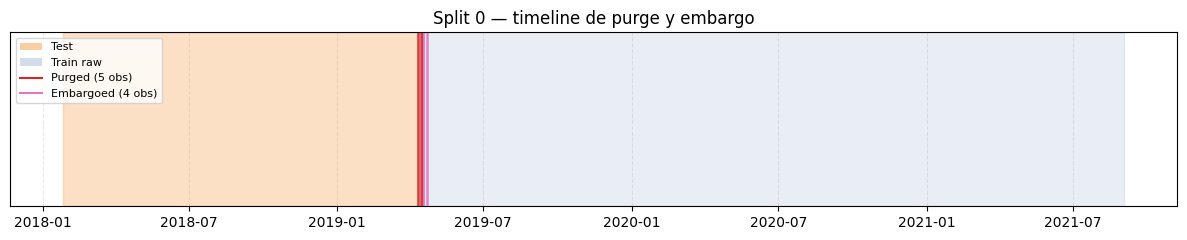

In [20]:
# ── Timeline Split 0 ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 2.5))

ax.axvspan(X.index[test_idx_0[0]], X.index[test_idx_0[-1]],
           alpha=0.25, color="#f58518", label="Test (grupos 0+1)")
ax.axvspan(X.index[train_idx_0[0]], X.index[train_idx_0[-1]],
           alpha=0.12, color="#4c78a8", label="Train raw")

for ts in purged_idx:
    ax.axvline(ts, color="#d62728", lw=1.2, alpha=0.8)
for ts in embargoed_idx:
    ax.axvline(ts, color="#e377c2", lw=1.2, alpha=0.8)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
handles = [
    Patch(facecolor="#f58518", alpha=0.4, label="Test"),
    Patch(facecolor="#4c78a8", alpha=0.25, label="Train raw"),
    Line2D([0],[0], color="#d62728", lw=1.5, label=f"Purged ({n_purged} obs)"),
    Line2D([0],[0], color="#e377c2", lw=1.5, label=f"Embargoed ({n_embargoed} obs)"),
]
ax.legend(handles=handles, fontsize=8, loc="upper left")
ax.set_title("Split 0 — timeline de purge y embargo")
ax.set_yticks([]); ax.grid(alpha=0.3, ls="--", axis="x")
plt.tight_layout(); plt.show()

---
## 9 · Corrida completa — IS y OOS por split

In [ ]:
def annualized_sr(returns: pd.Series, periods: int = 252) -> float:
    if len(returns) < 2 or returns.std() == 0:
        return 0.0
    return float(np.sqrt(periods) * returns.mean() / returns.std())


def run_split(sid, raw_tr, te, final_tr, tg):
    clf = make_clf()
    clf.fit(X.iloc[final_tr], y.iloc[final_tr])

    oos_proba = clf.predict_proba(X.iloc[te])[:, 1]
    predicted_y = (oos_proba >= 0.5).astype(int)
    target = y.iloc[te].values
    ret_5d = ret_fwd.iloc[te].values
    pnl = np.where(predicted_y == target, np.abs(ret_5d), -np.abs(ret_5d))
    oos_ret = pd.Series(pnl, index=X.index[te])

    is_proba = clf.predict_proba(X.iloc[final_tr])[:, 1]
    is_pred = (is_proba >= 0.5).astype(int)
    is_target = y.iloc[final_tr].values
    is_ret = pd.Series(
        np.where(is_pred == is_target,
                 np.abs(ret_fwd.iloc[final_tr].values),
                 -np.abs(ret_fwd.iloc[final_tr].values)),
        index=X.index[final_tr],
    )

    debug_df = pd.DataFrame({
        "timestamp": X.index[te],
        "feature_x": X.iloc[te]["feature_x"].values,
        "ret_fwd_5d": ret_5d,
        "target": target,
        "predicted_y": predicted_y,
        "pnl": pnl,
    }).set_index("timestamp")

    return {
        "split_id": sid,
        "test_groups": tg,
        "is_sr": annualized_sr(is_ret),
        "oos_sr": annualized_sr(oos_ret),
        "oos_returns": oos_ret,
        "oos_debug": debug_df,
    }


In [22]:
cpcv = CombinatorialPurgedKFold(
    n_groups=N,
    n_test_groups=k,
    t1=t1,
    pctEmbargo=pctEmbargo,
)
all_splits_data = list(cpcv.split(X))

results = []
oos_by_split = {}
debug_by_split = {}

for sid, (raw_tr, te, final_tr, tg) in enumerate(all_splits_data):
    r = run_split(sid, raw_tr, te, final_tr, tg)
    results.append({k2: v for k2, v in r.items() if k2 not in ("oos_returns", "oos_debug")})
    oos_by_split[sid] = r["oos_returns"]
    debug_by_split[sid] = r["oos_debug"]
    print(f"Split {sid:2d} | groups={tg} | IS_SR={r['is_sr']:6.2f} | OOS_SR={r['oos_sr']:6.2f}")

results_df = pd.DataFrame(results)
results_df


Split  0 | groups=(0, 1) | IS_SR= 24.71 | OOS_SR= 11.70
Split  1 | groups=(0, 2) | IS_SR= 23.70 | OOS_SR= 14.80
Split  2 | groups=(0, 3) | IS_SR= 23.90 | OOS_SR= 13.64
Split  3 | groups=(0, 4) | IS_SR= 25.66 | OOS_SR= 13.88
Split  4 | groups=(0, 5) | IS_SR= 24.72 | OOS_SR= 11.64
Split  5 | groups=(1, 2) | IS_SR= 25.82 | OOS_SR= 11.77
Split  6 | groups=(1, 3) | IS_SR= 27.13 | OOS_SR=  9.25
Split  7 | groups=(1, 4) | IS_SR= 27.98 | OOS_SR=  8.64
Split  8 | groups=(1, 5) | IS_SR= 25.78 | OOS_SR= 12.66
Split  9 | groups=(2, 3) | IS_SR= 25.80 | OOS_SR= 13.46
Split 10 | groups=(2, 4) | IS_SR= 27.35 | OOS_SR= 11.59
Split 11 | groups=(2, 5) | IS_SR= 26.30 | OOS_SR= 16.04
Split 12 | groups=(3, 4) | IS_SR= 28.08 | OOS_SR= 11.43
Split 13 | groups=(3, 5) | IS_SR= 26.28 | OOS_SR= 12.96
Split 14 | groups=(4, 5) | IS_SR= 26.25 | OOS_SR= 14.32


,split_id,test_groups,is_sr,oos_sr
0,0,"(0, 1)",24.706015,11.695828
1,1,"(0, 2)",23.702521,14.797831
2,2,"(0, 3)",23.900012,13.643529
3,3,"(0, 4)",25.659815,13.884584
4,4,"(0, 5)",24.720878,11.641209
5,5,"(1, 2)",25.823974,11.771565
6,6,"(1, 3)",27.128571,9.248187
7,7,"(1, 4)",27.976034,8.635442
8,8,"(1, 5)",25.777753,12.664137
9,9,"(2, 3)",25.798823,13.462920


### Tabla OOS simple por split

Cada split produce una tabla OOS muy simple con una sola feature:

- `timestamp`
- `feature_x`
- `ret_fwd_5d`
- `target`
- `predicted_y`
- `pnl`

Regla de PnL usada en el notebook:

$$
pnl_t = egin{cases}
+|r^{fwd}_{t,5d}| & 	ext{si } predicted\_y_t = target_t \
-|r^{fwd}_{t,5d}| & 	ext{si } predicted\_y_t 
eq target_t
\end{cases}
$$


In [23]:
print("=" * 70)
print("Split 0 · Tabla OOS simple")
print("=" * 70)
print(debug_by_split[0].head(40).round(6).to_string())


DEBUG · Splits OOS individuales
split  0 | n=314 | start=2018-01-26 | end=2019-04-10 | mean= 0.011365 | std= 0.015426 | sr= 11.6958
2018-01-26    0.018831
2018-01-29    0.018165
2018-01-30    0.023021
2018-01-31    0.019594
2018-02-01    0.021863
2018-02-02    0.025301
2018-02-05    0.035277
2018-02-06    0.031523
2018-02-07    0.028013
2018-02-08    0.023108
2018-02-09    0.021848
2018-02-12    0.015790
2018-02-13    0.014919
2018-02-14    0.011506
2018-02-15    0.009257
2018-02-16    0.008907
2018-02-19    0.006151
2018-02-20    0.006208
2018-02-21    0.007123
2018-02-22    0.012603
2018-02-23    0.012398
2018-02-26    0.013244
2018-02-27    0.018992
2018-02-28    0.024315
2018-03-01    0.026904
2018-03-02    0.027115
2018-03-05    0.027522
2018-03-06    0.026686
2018-03-07    0.020055
2018-03-08    0.016190
2018-03-09    0.014173
2018-03-12   -0.010579
2018-03-13   -0.006986
2018-03-14    0.018790
2018-03-15    0.016598
2018-03-16    0.022351
2018-03-19    0.018190
2018-03-20    0.0

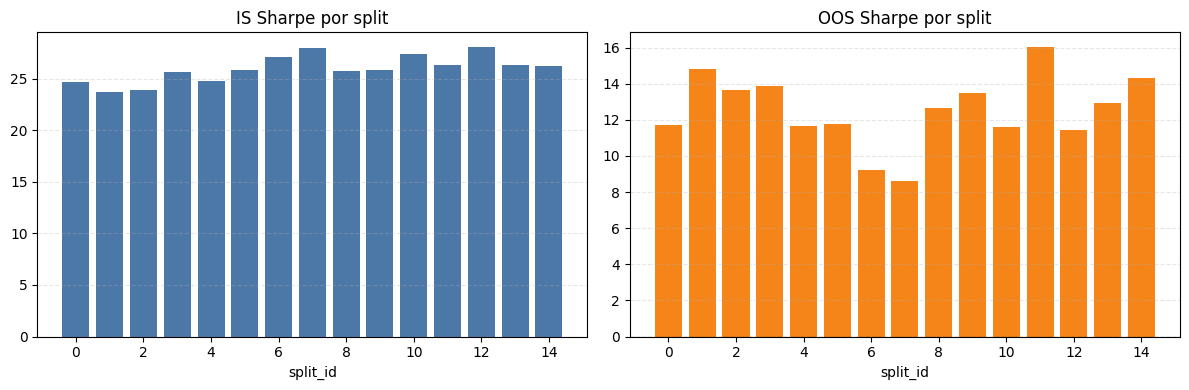

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(results_df["split_id"], results_df["is_sr"],  color="#4c78a8")
axes[0].set_title("IS Sharpe por split")
axes[0].set_xlabel("split_id")
axes[0].grid(alpha=0.3, ls="--", axis="y")

axes[1].bar(results_df["split_id"], results_df["oos_sr"], color="#f58518")
axes[1].axhline(0, color="black", ls="--", lw=0.8)
axes[1].set_title("OOS Sharpe por split")
axes[1].set_xlabel("split_id")
axes[1].grid(alpha=0.3, ls="--", axis="y")
plt.tight_layout(); plt.show()


### Paths y Sharpe global CPCV

$$SR^{CPCV}_{OOS} = \frac{1}{\phi} \sum_{i=1}^{\phi} SR_{\text{path}_i}$$

Cada path concatena los retornos OOS de los splits cuyo test cubre los N grupos
exactamente una vez, dando una trayectoria OOS sin gaps ni overlaps.

In [25]:
def get_paths(N: int, k: int) -> list:
    all_combos  = list(combinations(range(N), k))
    combo_to_id = {c: i for i, c in enumerate(all_combos)}
    n_paths     = len(all_combos) * k // N

    def backtrack(remaining, covered, path):
        if len(covered) == N and len(path) == N // k:
            yield list(path)
            return
        if not remaining:
            return
        c, rest = remaining[0], remaining[1:]
        if not set(c) & covered:
            yield from backtrack(rest, covered | set(c), path + [combo_to_id[c]])
        yield from backtrack(rest, covered, path)

    seen, unique = set(), []
    for p in backtrack(all_combos, set(), []):
        key = tuple(sorted(p))
        if key not in seen:
            seen.add(key); unique.append(p)
        if len(unique) == n_paths:
            break
    return unique


paths = get_paths(N, k)
print(f"Numero de paths (phi): {len(paths)}")
for pid, split_ids in enumerate(paths):
    print(f"  PATH {pid}: splits {split_ids}")

Numero de paths (phi): 5
  PATH 0: splits [0, 9, 14]
  PATH 1: splits [0, 10, 13]
  PATH 2: splits [0, 11, 12]
  PATH 3: splits [1, 6, 14]
  PATH 4: splits [1, 7, 13]


In [26]:
path_summary = []
path_returns = {}

for pid, split_ids in enumerate(paths):
    oos_series = pd.concat([oos_by_split[sid] for sid in split_ids]).sort_index().dropna()
    path_returns[pid] = oos_series
    path_summary.append({
        "path_id": pid,
        "split_ids": tuple(split_ids),
        "n_obs": len(oos_series),
        "oos_sr": annualized_sr(oos_series),
        "mean_return": oos_series.mean(),
        "std_return": oos_series.std(),
        "final_cum_ret": float(np.exp(oos_series.sum())),
    })

path_df = pd.DataFrame(path_summary)
path_df


,path_id,split_ids,n_obs,oos_sr,mean_return,std_return,final_cum_ret
0,0,"(0, 9, 14)",941,13.089244,0.011943,0.014485,71610.823368
1,1,"(0, 10, 13)",941,12.052847,0.011353,0.014953,41204.637312
2,2,"(0, 11, 12)",941,12.899015,0.011839,0.014570,64956.444666
3,3,"(1, 6, 14)",941,12.593585,0.011668,0.014708,55339.679452
4,4,"(1, 7, 13)",941,11.938322,0.011284,0.015005,38636.335462


In [27]:
print("=" * 70)
print("Retornos timeline completos por path y Sharpe explícito")
print("=" * 70)

for pid, series in path_returns.items():
    mu = series.mean()
    sigma = series.std()
    sr = annualized_sr(series)

    print(f"\nPATH {pid}")
    print(f"split_ids = {paths[pid]}")
    print(f"n_obs = {len(series)}")
    print("retornos timeline del path:")
    print(series.to_string())
    print()
    print("aplicando fórmula del Sharpe:")
    print(f"mean_return = {mu:.8f}")
    print(f"std_return  = {sigma:.8f}")
    print(f"sharpe = sqrt(252) * mean / std = {sr:.8f}")
    print("-" * 70)


DEBUG · Retornos timeline completos por path y Sharpe explícito

PATH 0
split_ids = [0, 9, 14]
n_obs = 936
retornos timeline del path:
2018-01-26    0.018831
2018-01-29    0.018165
2018-01-30    0.023021
2018-01-31    0.019594
2018-02-01    0.021863
2018-02-02    0.025301
2018-02-05    0.035277
2018-02-06    0.031523
2018-02-07    0.028013
2018-02-08    0.023108
2018-02-09    0.021848
2018-02-12    0.015790
2018-02-13    0.014919
2018-02-14    0.011506
2018-02-15    0.009257
2018-02-16    0.008907
2018-02-19    0.006151
2018-02-20    0.006208
2018-02-21    0.007123
2018-02-22    0.012603
2018-02-23    0.012398
2018-02-26    0.013244
2018-02-27    0.018992
2018-02-28    0.024315
2018-03-01    0.026904
2018-03-02    0.027115
2018-03-05    0.027522
2018-03-06    0.026686
2018-03-07    0.020055
2018-03-08    0.016190
2018-03-09    0.014173
2018-03-12   -0.010579
2018-03-13   -0.006986
2018-03-14    0.018790
2018-03-15    0.016598
2018-03-16    0.022351
2018-03-19    0.018190
2018-03-20    

### Auditoría de paths

En el notebook simplificado:

1. el modelo ve solo `feature_x`,
2. cada split genera una tabla OOS simple,
3. el path concatena los `pnl` OOS de los splits que le corresponden,
4. el Sharpe se calcula sobre esa serie final del path.


In [28]:
cpcv_oos = path_df["oos_sr"].mean()
cpcv_is  = results_df["is_sr"].mean()
print(f"IS  SR (media splits) : {cpcv_is:.4f}")
print(f"OOS SR (media paths)  : {cpcv_oos:.4f}")
print(f"Delta SR              : {cpcv_is - cpcv_oos:.4f}")


IS  SR (media splits) : 25.9636
OOS SR (media paths)  : 12.5146
Delta SR              : 13.4489


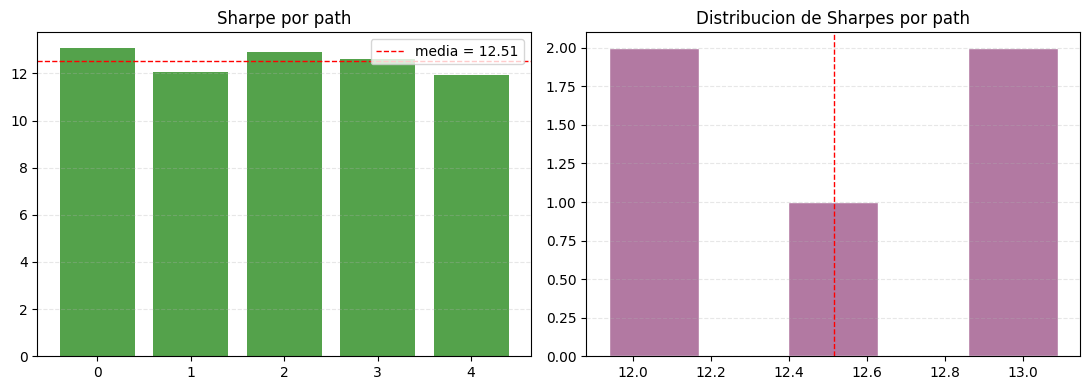

In [29]:
path_srs = path_df["oos_sr"].values

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(path_df["path_id"], path_srs, color="#54a24b")
axes[0].axhline(path_srs.mean(), color="red", ls="--", lw=1.0,
                label=f"media = {path_srs.mean():.2f}")
axes[0].set_title("Sharpe por path"); axes[0].legend()
axes[0].grid(alpha=0.3, ls="--", axis="y")

axes[1].hist(path_srs, bins=min(5, len(path_srs)), color="#b279a2", edgecolor="white")
axes[1].axvline(path_srs.mean(), color="red", ls="--", lw=1.0)
axes[1].set_title("Distribucion de Sharpes por path")
axes[1].grid(alpha=0.3, ls="--", axis="y")
plt.tight_layout(); plt.show()

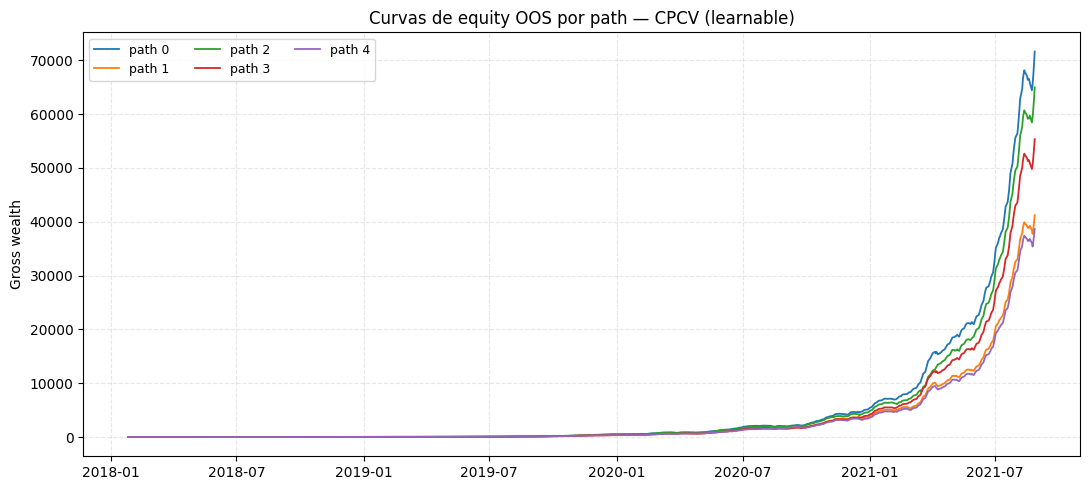

In [30]:
fig, ax = plt.subplots(figsize=(11, 5))
for pid, series in path_returns.items():
    eq = np.exp(series.sort_index().cumsum())
    ax.plot(eq.index, eq.values, lw=1.3, label=f"path {pid}")
ax.set_title("Curvas de equity OOS por path — CPCV (learnable)")
ax.set_ylabel("Gross wealth")
ax.legend(ncol=3, fontsize=9); ax.grid(alpha=0.3, ls="--")
plt.tight_layout(); plt.show()

---
## 10 · Comparación de métodos

| Método | Combinatorio | Purge | Embargo |
|--------|:---:|:---:|:---:|
| **CCV** | ✓ | ✗ | ✗ |
| **CCV + Purge** | ✓ | ✓ | ✗ |
| **CCV + Embargo** | ✓ | ✗ | ✓ |
| **CPCV** | ✓ | ✓ | ✓ |
| **WalkForward** | ✗ | ✗ | ✗ |
| **KFold** | ✗ | ✗ | ✗ |

Los métodos combinatorios generan más paths OOS y un estimador de Sharpe más estable.
CPCV es la variante que cierra todas las fugas de información.

In [31]:
from sklearn.model_selection import KFold

def run_method(method_name: str, splits_iter) -> dict:
    is_srs, oos_rets = [], []
    for tr, te in splits_iter:
        if len(tr) < 10 or len(te) < 5:
            continue
        clf = make_clf()
        clf.fit(X.iloc[tr], y.iloc[tr])
        is_r  = pd.Series(
            np.where(clf.predict_proba(X.iloc[tr])[:, 1] >= 0.5, 1.0, -1.0)
            * ret_fwd.iloc[tr].values, index=X.index[tr])
        oos_r = pd.Series(
            np.where(clf.predict_proba(X.iloc[te])[:, 1] >= 0.5, 1.0, -1.0)
            * ret_fwd.iloc[te].values, index=X.index[te])
        is_srs.append(annualized_sr(is_r))
        oos_rets.append(oos_r)

    all_oos = pd.concat(oos_rets).sort_index() if oos_rets else pd.Series(dtype=float)
    return {
        "method"  : method_name,
        "IS_SR"   : float(np.mean(is_srs)) if is_srs else float("nan"),
        "OOS_SR"  : annualized_sr(all_oos),
        "Delta_SR": float(np.mean(is_srs)) - annualized_sr(all_oos) if is_srs else float("nan"),
    }


# CCV — combinatorio puro, sin ninguna proteccion
def ccv_splits_raw(n_obs, N, k):
    groups = np.array_split(np.arange(n_obs), N)
    for test_groups in combinations(range(N), k):
        te = np.concatenate([groups[g] for g in test_groups])
        tr = np.concatenate([groups[g] for g in range(N) if g not in test_groups])
        yield tr, te


# CCV + Purge — combinatorio con purge, sin embargo
def ccv_splits_purge(n_obs, N, k, index, t1):
    groups = np.array_split(np.arange(n_obs), N)
    for test_groups in combinations(range(N), k):
        te        = np.concatenate([groups[g] for g in test_groups])
        tr        = np.concatenate([groups[g] for g in range(N) if g not in test_groups])
        tr_purged = getTrainTimes(t1.iloc[tr], t1.iloc[te])
        final_tr  = np.array([index.get_loc(ts) for ts in tr_purged.index])
        yield final_tr, te


# CCV + Embargo — combinatorio con embargo, sin purge
def ccv_splits_embargo(n_obs, N, k, index, t1, pctEmbargo):
    groups = np.array_split(np.arange(n_obs), N)
    mbrg   = getEmbargoTimes(index, pctEmbargo)
    for test_groups in combinations(range(N), k):
        te         = np.concatenate([groups[g] for g in test_groups])
        tr         = np.concatenate([groups[g] for g in range(N) if g not in test_groups])
        kept       = np.array(index[tr])
        blocked    = np.zeros(len(kept), dtype=bool)
        sorted_te  = np.sort(te)
        breaks     = np.where(np.diff(sorted_te) > 1)[0] + 1
        for block in np.split(sorted_te, breaks):
            block_end   = index[block[-1]]
            embargo_end = mbrg.get(block_end, block_end)
            in_emb      = np.array((pd.Index(kept) > block_end) & (pd.Index(kept) <= embargo_end))
            blocked    |= in_emb
        final_tr = np.array([index.get_loc(ts) for ts in kept[~blocked]])
        yield final_tr, te


# Walk-Forward
def wf_splits(X, train_years=2, test_months=4):
    n = len(X)
    train_obs, test_obs = int(train_years * 252), int(test_months * 21)
    start = 0
    while start + train_obs + test_obs <= n:
        yield (np.arange(start, start + train_obs),
               np.arange(start + train_obs, start + train_obs + test_obs))
        start += test_obs


In [32]:
comparison_df = pd.DataFrame([
    run_method("CCV",
               ccv_splits_raw(n_obs, N, k)),
    run_method("CCV+Purge",
               ccv_splits_purge(n_obs, N, k, X.index, t1)),
    run_method("CCV+Embargo",
               ccv_splits_embargo(n_obs, N, k, X.index, t1, pctEmbargo)),
    run_method("CPCV",
               ((final_tr, te) for _, te, final_tr, _ in all_splits_data)),
    run_method("WalkForward",
               wf_splits(X, train_years=2, test_months=4)),
    run_method("KFold",
               KFold(n_splits=5, shuffle=False).split(X)),
])
comparison_df

,method,IS_SR,OOS_SR,Delta_SR
0,CCV,25.911356,12.357443,13.553913
1,CCV+Purge,25.999458,12.542058,13.457400
2,CCV+Embargo,25.874922,12.342344,13.532578
3,CPCV,25.963552,12.381618,13.581934
4,WalkForward,26.069172,12.761721,13.307451
5,KFold,24.723747,13.540226,11.183521


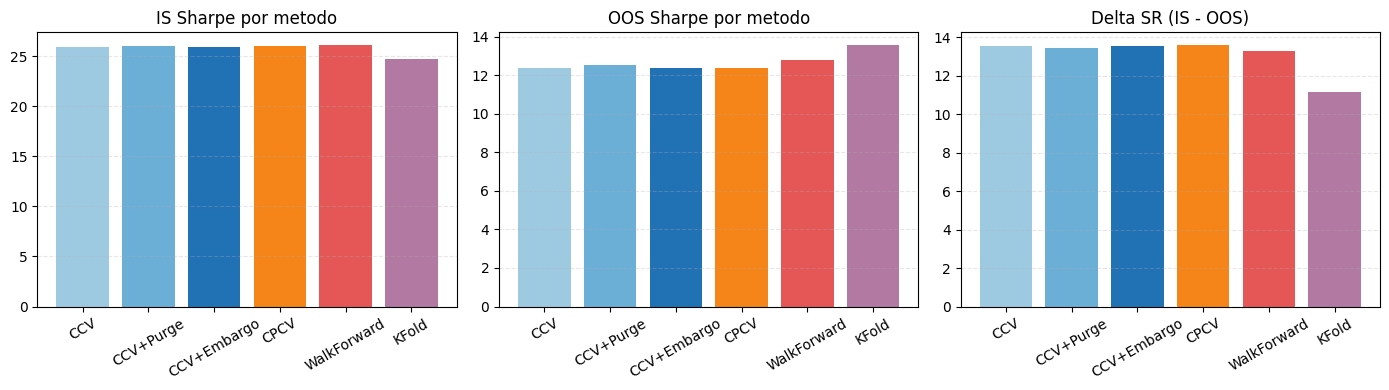

In [33]:
colors = ["#9ecae1","#6baed6","#2171b5","#f58518","#e45756","#b279a2"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(
        axes,
        ["IS_SR", "OOS_SR", "Delta_SR"],
        ["IS Sharpe por metodo", "OOS Sharpe por metodo", "Delta SR (IS - OOS)"]):
    ax.bar(comparison_df["method"], comparison_df[col], color=colors)
    ax.set_title(title)
    ax.grid(alpha=0.3, ls="--", axis="y")
    ax.tick_params(axis="x", rotation=30)
    ax.axhline(0, color="black", ls="--", lw=0.7)
plt.tight_layout(); plt.show()

**Cómo leer la comparación:**

- **OOS Sharpe** — CPCV da el estimador más conservador. CCV sin protección puede inflar
  el OOS porque sus splits contienen look-ahead bias.
- **Delta SR** — cuánto cae el Sharpe al pasar de IS a OOS. Un Delta alto con método sin
  purge/embargo indica que el estimador OOS estaba contaminado, no que el modelo sea peor.
- **WalkForward y KFold** — menos splits, estimador menos estable; además no controlan
  solapamiento de labels.

---
## 11 · Los tres escenarios

In [34]:
def evaluate_scenario(sc_payload: dict, label: str) -> dict:
    Xs, ys, t1s, retf = (
        sc_payload["X"], sc_payload["y"],
        sc_payload["t1"], sc_payload["ret_fwd"]
    )
    cpcv_scn = CombinatorialPurgedKFold(
        n_groups=N,
        n_test_groups=k,
        t1=t1s,
        pctEmbargo=pctEmbargo,
    )
    sp_data  = list(cpcv_scn.split(Xs))
    is_srs, oos_rets = [], []

    for _, te, final_tr, _ in sp_data:
        clf = make_clf()
        clf.fit(Xs.iloc[final_tr], ys.iloc[final_tr])

        is_pred = (clf.predict_proba(Xs.iloc[final_tr])[:, 1] >= 0.5).astype(int)
        is_target = ys.iloc[final_tr].values
        is_r = pd.Series(
            np.where(is_pred == is_target,
                     np.abs(retf.iloc[final_tr].values),
                     -np.abs(retf.iloc[final_tr].values))
        )
        is_srs.append(annualized_sr(is_r))

        oos_pred = (clf.predict_proba(Xs.iloc[te])[:, 1] >= 0.5).astype(int)
        oos_target = ys.iloc[te].values
        oos_r = pd.Series(
            np.where(oos_pred == oos_target,
                     np.abs(retf.iloc[te].values),
                     -np.abs(retf.iloc[te].values)),
            index=Xs.index[te]
        )
        oos_rets.append(oos_r)

    all_oos = pd.concat(oos_rets).sort_index()
    return {
        "scenario": label,
        "IS_SR": float(np.mean(is_srs)),
        "OOS_SR": annualized_sr(all_oos),
        "Delta_SR": float(np.mean(is_srs)) - annualized_sr(all_oos),
    }


scenario_results = pd.DataFrame([
    evaluate_scenario(learnable, "learnable"),
    evaluate_scenario(noise,     "noise"),
    evaluate_scenario(shock,     "shock"),
])
scenario_results


,scenario,IS_SR,OOS_SR,Delta_SR
0,learnable,25.963552,12.381618,13.581934
1,noise,16.061571,0.474123,15.587448
2,shock,18.290391,8.736266,9.554125


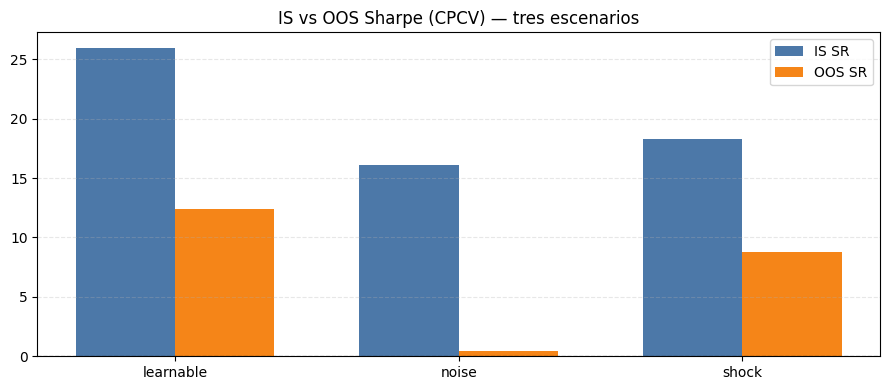

In [35]:
x, w = np.arange(len(scenario_results)), 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, scenario_results["IS_SR"],  w, label="IS SR",  color="#4c78a8")
ax.bar(x + w/2, scenario_results["OOS_SR"], w, label="OOS SR", color="#f58518")
ax.axhline(0, color="black", ls="--", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(scenario_results["scenario"])
ax.set_title("IS vs OOS Sharpe (CPCV) — tres escenarios")
ax.legend(); ax.grid(alpha=0.3, ls="--", axis="y")
plt.tight_layout(); plt.show()

**Interpretacion:**

- **learnable** — IS y OOS altos, Delta moderado: hay señal real que el modelo captura.
- **noise** — IS inflado (el modelo memoriza ruido), OOS ~0: CPCV detecta que no hay señal.
- **shock** — IS alto, OOS intermedio: el shock concentra retornos en un periodo puntual.

---
## Resumen

In [36]:
print("=" * 60)
print("  CPCV — resumen learnable")
print("=" * 60)
print(f"  N (grupos)         : {N}")
print(f"  k (grupos test)    : {k}")
print(f"  pctEmbargo         : {pctEmbargo:.1%}")
print(f"  C(N,k) splits      : {comb(N, k)}")
print(f"  Paths (phi)        : {len(paths)}")
print(f"  IS  SR (splits)    : {results_df['is_sr'].mean():.4f}")
print(f"  OOS SR (paths)     : {path_df['oos_sr'].mean():.4f}")
print(f"  Delta SR           : {results_df['is_sr'].mean() - path_df['oos_sr'].mean():.4f}")
print("=" * 60)
print()
print("Comparacion de metodos (learnable):")
print(comparison_df[["method","IS_SR","OOS_SR","Delta_SR"]].to_string(index=False))
print()
print("Por escenario (CPCV):")
print(scenario_results.to_string(index=False))

  CPCV — resumen learnable
  N (grupos)         : 6
  k (grupos test)    : 2
  pctEmbargo         : 1.0%
  C(N,k) splits      : 15
  Paths (phi)        : 5
  IS  SR (splits)    : 25.9636
  OOS SR (paths)     : 12.5146
  Delta SR           : 13.4489

Comparacion de metodos (learnable):
     method     IS_SR    OOS_SR  Delta_SR
        CCV 25.911356 12.357443 13.553913
  CCV+Purge 25.999458 12.542058 13.457400
CCV+Embargo 25.874922 12.342344 13.532578
       CPCV 25.963552 12.381618 13.581934
WalkForward 26.069172 12.761721 13.307451
      KFold 24.723747 13.540226 11.183521

Por escenario (CPCV):
 scenario     IS_SR    OOS_SR  Delta_SR
learnable 25.963552 12.381618 13.581934
    noise 16.061571  0.474123 15.587448
    shock 18.290391  8.736266  9.554125
